# Project Task 3: Bank Customer Churn Prediction
### **Internship: DevelopersHub Corporation**

**Objective:**
In this task, my goal is to build a classification model that can tell us if a customer will leave the bank or stay.
 I am using the Churn Modelling dataset for this analysis.
```

In [49]:
# Importing necessary tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

print("Libraries loaded successfully.")

Libraries loaded successfully.


**Data Loading**

In [50]:

churn_df = pd.read_csv("Churn_Modelling.csv")

# Looking at the first 5 rows
print("Data Preview:")
print(churn_df.head())

Data Preview:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  

**Basic Checks**

In [51]:



print("Dataset Shape:", churn_df.shape)
print("\nColumn Information:")
churn_df.info()

Dataset Shape: (10000, 14)

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


**Data Cleaning**

In [52]:



churn_df = churn_df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

print("Columns dropped. Remaining columns:", churn_df.columns.tolist())

Columns dropped. Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


**Encoding**

In [53]:


# Converting Gender and Geography into numbers
encoder = LabelEncoder()

churn_df["Gender"] = encoder.fit_transform(churn_df["Gender"])
churn_df["Geography"] = encoder.fit_transform(churn_df["Geography"])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


*Splitting and Scaling*

In [54]:


# Splitting data into features (X) and target (y)
X = churn_df.drop("Exited", axis=1)
y = churn_df["Exited"]

# 80% train and 20% test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data for improving model performance
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Data split and scaling is done.")

Data split and scaling is done.


*Model Traning*

In [55]:


# Using Logistic Regression with a higher max_iter
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

print("Logistic Regression model training finished.")

Logistic Regression model training finished.


*Evaluation & Confusion Matrix*


The Model Accuracy is: 0.8155


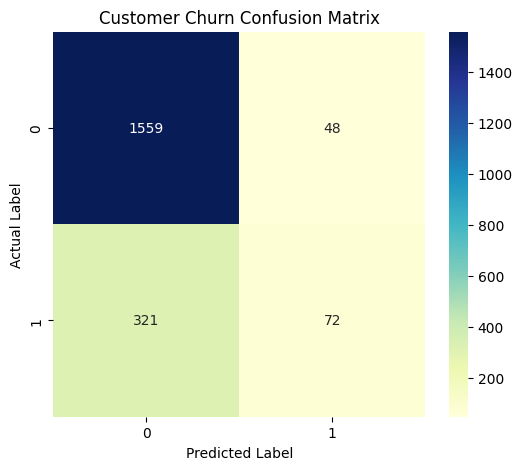

In [56]:


#  predictions and  accuracy
y_preds = lr_model.predict(X_test)
acc_score = accuracy_score(y_test, y_preds)
print("The Model Accuracy is:", acc_score)

# Plotting Confusion Matrix
cm_data = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_data, annot=True, fmt="d", cmap="YlGnBu") # Changed color from Blues to YlGnBu
plt.title("Customer Churn Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

*CHECKING FEATURES*


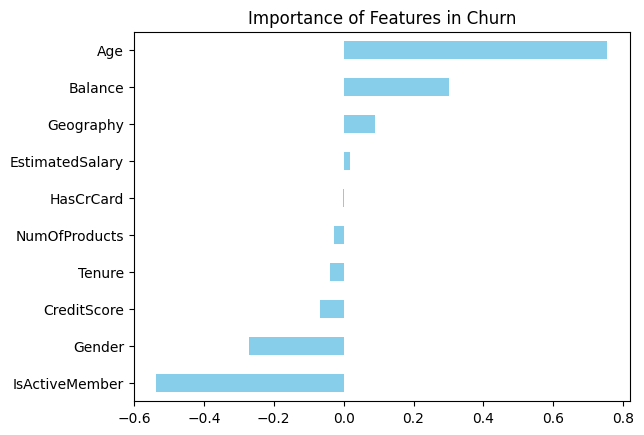

In [57]:


# Checking for important features. 
feature_weights = pd.Series(lr_model.coef_[0], index=X.columns)
feature_weights.sort_values().plot(kind='barh', color='skyblue')
plt.title("Importance of Features in Churn")
plt.show()


## Key Insights

1.  My model achieved an accuracy of around 81%, that is  good for a basic Logistic Regression.
2.  From the importance graph, factors like 'Age' and 'IsActiveMember' have a strong impact on whether a customer stays or leaves.
3.  Without scaling the model was giving convergence warnings.
4.  During this task, I learned how to handle categorical data and how to interpret model coefficients.

